Scenarios: 20 wind x 20 price x 4 SI = 1600 total
Scenario probability: pi = 0.000625

Building Gurobi model...
Set parameter OutputFlag to value 1
Model: 0 variables | 0 constraints
Solving...
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) i7-10750H CPU @ 2.60GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 38400 rows, 76824 columns and 115200 nonzeros (Max)
Model fingerprint: 0x5df0ab56
Model has 76184 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [5e-06, 1e+02]
  Bounds range     [5e+02, 5e+02]
  RHS range        [1e-01, 5e+02]

Presolve removed 38400 rows and 76824 columns
Presolve time: 0.13s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    3.3312951e+05   0.000000e+00   0.000000e+00      0s

Solved in 0

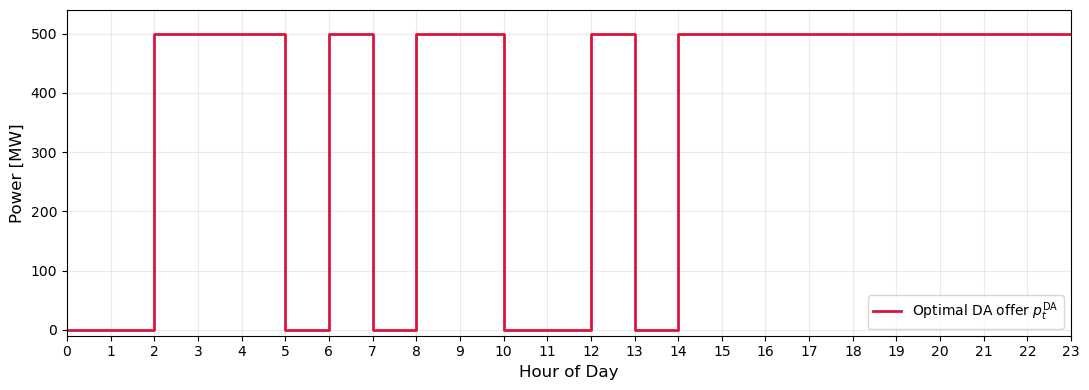

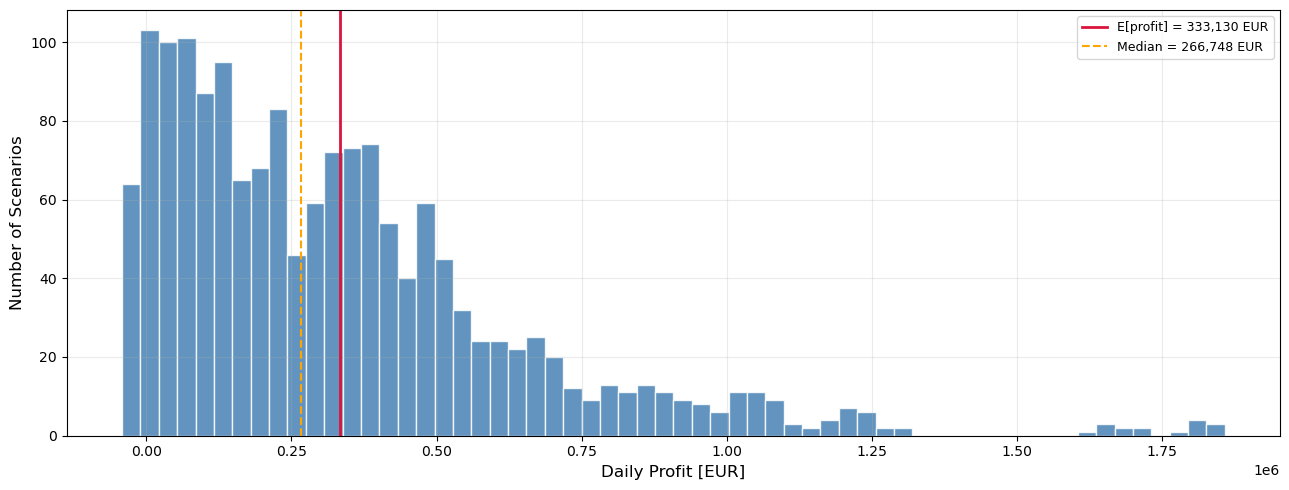

In [8]:
"""
Task 1.1 — Optimal Offering Strategy Under a One-Price Balancing Scheme
========================================================================
Stochastic LP formulation following Lecture 8. Solver: Gurobi.

Combined scenarios: 20 wind x 20 price x 4 SI = 1,600  (pi_w = 1/1600)

Objective:
  max  sum_t sum_w  pi_w * [ lambda_tw^DA * p_t^DA
                              + BP_tw * Delta_tw_up
                              - BP_tw * Delta_tw_down ]

  BP_tw = 1.25 * lambda_tw^DA  if SI_w(t) = 1  (system deficit)
        = 0.85 * lambda_tw^DA  if SI_w(t) = 0  (system surplus)

Variables:
  p_t^DA       -- first-stage DA offer [MW], NOT scenario-indexed
  Delta_tw_up  -- power excess  (wind > DA offer) [MW], second-stage
  Delta_tw_down-- power deficit (wind < DA offer) [MW], second-stage

Constraints:
  0 <= p_t^DA <= P_nom
  Delta_tw_up - Delta_tw_down = p_tw^wind - p_t^DA    for all t, w
  Delta_tw_up >= 0,  Delta_tw_down >= 0               for all t, w
"""

import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import itertools

# =============================================================================
# Configuration
# =============================================================================
WIND_CSV    = 'wind_scenarios_DK2.csv'
PRICE_CSV   = 'price_scenarios_DK2.csv'
SI_CSV      = 'si_scenarios.csv'

P_NOM       = 500.0   # MW installed capacity
BP_DEFICIT  = 1.25    # BP multiplier when SI = 1 (system deficit)
BP_SURPLUS  = 0.85    # BP multiplier when SI = 0 (system surplus)

# =============================================================================
# Load scenario data
# =============================================================================
wind_df  = pd.read_csv(WIND_CSV,  index_col='hour')      # (24, 20)
price_df = pd.read_csv(PRICE_CSV, index_col='hour')      # (24, 20)
si_df    = pd.read_csv(SI_CSV,    index_col='scenario')  # (4,  24)

T       = 24
N_WIND  = wind_df.shape[1]           # 20
N_PRICE = price_df.shape[1]          # 20
N_SI    = si_df.shape[0]             # 4
N_SCEN  = N_WIND * N_PRICE * N_SI   # 1600
PI      = 1.0 / N_SCEN

print(f"Scenarios: {N_WIND} wind x {N_PRICE} price x {N_SI} SI = {N_SCEN} total")
print(f"Scenario probability: pi = {PI:.6f}")

# =============================================================================
# Build combined scenario matrices  shape: (T=24, N_SCEN=1600)
# omega = (wind_i, price_j, si_k) -- full Cartesian product
# =============================================================================
combos = list(itertools.product(range(N_WIND), range(N_PRICE), range(N_SI)))

wind_mat  = np.zeros((T, N_SCEN))
price_mat = np.zeros((T, N_SCEN))
bp_mat    = np.zeros((T, N_SCEN))

for omega, (wi, pi_i, si_k) in enumerate(combos):
    wind_mat[:, omega]  = wind_df.iloc[:, wi].values
    price_mat[:, omega] = price_df.iloc[:, pi_i].values
    si_path             = si_df.iloc[si_k].values          # (24,) binary
    bp_mat[:, omega]    = np.where(
        si_path == 1,
        price_mat[:, omega] * BP_DEFICIT,
        price_mat[:, omega] * BP_SURPLUS
    )

# =============================================================================
# Build and solve the stochastic LP with Gurobi
# =============================================================================
print("\nBuilding Gurobi model...")
m = gp.Model("task1_1_one_price")
m.setParam("OutputFlag", 1)

# First-stage: DA offer per hour (T,)
p_DA = m.addMVar(T, lb=0.0, ub=P_NOM, name="p_DA")

# Second-stage: excess and deficit (T, N_SCEN)
delta_up   = m.addMVar((T, N_SCEN), lb=0.0, name="delta_up")
delta_down = m.addMVar((T, N_SCEN), lb=0.0, name="delta_down")

# Objective coefficients
# DA term: for each hour t, coefficient on p_DA[t] = sum_w pi * lambda_tw
da_coeff = (PI * price_mat).sum(axis=1)  # (T,)

# Balancing term: pi * BP_tw for each (t, w)
bp_coeff = PI * bp_mat  # (T, N_SCEN)

m.setObjective(
    da_coeff @ p_DA
    + gp.quicksum(
        bp_coeff[t, w] * delta_up[t, w] - bp_coeff[t, w] * delta_down[t, w]
        for t in range(T) for w in range(N_SCEN)
    ),
    GRB.MAXIMIZE
)

# Imbalance constraints: Delta_up - Delta_down = wind - p_DA  for all t, w
for t in range(T):
    m.addConstr(
        delta_up[t, :] - delta_down[t, :] == wind_mat[t, :] - p_DA[t],
        name=f"imbalance_t{t}"
    )

print(f"Model: {m.NumVars:,} variables | {m.NumConstrs:,} constraints")
print("Solving...")
m.optimize()

if m.Status != GRB.OPTIMAL:
    raise RuntimeError(f"No optimal solution found. Gurobi status: {m.Status}")

# =============================================================================
# Extract results
# =============================================================================
p_DA_opt       = p_DA.X                                      # (24,)
delta_up_opt   = delta_up.X                                  # (24, 1600)
delta_down_opt = delta_down.X                                # (24, 1600)

# Per-scenario daily profit (EUR)
da_revenue       = (price_mat * p_DA_opt[:, None]).sum(axis=0)
bal_revenue      = (bp_mat * (delta_up_opt - delta_down_opt)).sum(axis=0)
scenario_profits = da_revenue + bal_revenue                  # (1600,)
expected_profit  = scenario_profits.mean()

print(f"\nObjective value:      {m.ObjVal:,.2f} EUR")
print(f"Verified exp. profit: {expected_profit:,.2f} EUR")

# =============================================================================
# All-or-nothing analysis
# =============================================================================
p_deficit      = si_df.values.mean()
e_bp_mult      = p_deficit * BP_DEFICIT + (1 - p_deficit) * BP_SURPLUS
threshold_p    = (1.0 - BP_SURPLUS) / (BP_DEFICIT - BP_SURPLUS)  # = 0.375
aon            = e_bp_mult > 1.0

# =============================================================================
# Console summary
# =============================================================================
print("\n" + "=" * 62)
print("  TASK 1.1 RESULTS -- ONE-PRICE SCHEME")
print("=" * 62)
print(f"\n  Expected profit      : {expected_profit:>13,.2f} EUR")
print(f"  Std deviation        : {scenario_profits.std():>13,.2f} EUR")
print(f"  Min profit           : {scenario_profits.min():>13,.2f} EUR")
print(f"  5th  percentile      : {np.percentile(scenario_profits,  5):>13,.2f} EUR")
print(f"  Median               : {np.median(scenario_profits):>13,.2f} EUR")
print(f"  95th percentile      : {np.percentile(scenario_profits, 95):>13,.2f} EUR")
print(f"  Max profit           : {scenario_profits.max():>13,.2f} EUR")

print(f"\n  -- All-or-nothing analysis --")
print(f"  Avg deficit prob p       : {p_deficit:.4f}")
print(f"  E[BP] multiplier         : {e_bp_mult:.4f}  (p*1.25 + (1-p)*0.85)")
print(f"  Threshold for AoN        : p > {threshold_p:.4f}")
print(f"  Conclusion               : {'AoN -- withhold all from DA' if aon else 'No AoN -- offer tracks mean wind'}")

print(f"\n  -- Optimal DA offers per hour --")
print(f"  {'Hour':<6} {'p_DA (MW)':>10}  {'Mean wind':>10}  {'% Cap':>7}")
print("  " + "-" * 40)
for t in range(T):
    mw   = wind_mat[t, :].mean()
    flag = "  <- ZERO (withheld)" if p_DA_opt[t] < 0.5 else \
           "  <- FULL 500 MW"     if p_DA_opt[t] > P_NOM - 0.5 else ""
    print(f"  {t:<6} {p_DA_opt[t]:>10.2f}  {mw:>10.2f}  {p_DA_opt[t]/P_NOM*100:>6.1f}%{flag}")
print("=" * 62)

# =============================================================================
# Export results to CSV
# =============================================================================
pd.DataFrame({
    'hour'        : range(T),
    'p_DA_opt_MW' : p_DA_opt,
    'mean_wind_MW': wind_mat.mean(axis=1),
    'pct_capacity': p_DA_opt / P_NOM * 100,
}).to_csv('task1_1_DA_offers.csv', index=False)

pd.DataFrame({
    'scenario'  : range(N_SCEN),
    'profit_EUR': scenario_profits,
}).to_csv('task1_1_scenario_profits.csv', index=False)

print("\nSaved: task1_1_DA_offers.csv")
print("Saved: task1_1_scenario_profits.csv")

# =============================================================================
# Plot 1 -- Optimal DA offers vs mean wind
# =============================================================================
hours = np.arange(T)

fig, ax = plt.subplots(figsize=(11, 4))

ax.step(hours, p_DA_opt, where='post', color='crimson', linewidth=2,
        label=r'Optimal DA offer $p_t^{\mathrm{DA}}$')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Power [MW]', fontsize=12)
ax.set_xticks(hours)
ax.set_xlim(0, T - 1)
ax.set_ylim(-10, P_NOM + 40)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('task1_1_DA_offers.pdf', dpi=150)
print("Saved: task1_1_DA_offers.pdf")

# =============================================================================
# Plot 2 -- Profit distribution
# =============================================================================
plt.figure(figsize=(13, 5))
plt.hist(scenario_profits, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(expected_profit,
            color='crimson', linewidth=2,
            label=f'E[profit] = {expected_profit:,.0f} EUR')
plt.axvline(np.median(scenario_profits),
            color='orange', linewidth=1.5, linestyle='--',
            label=f'Median = {np.median(scenario_profits):,.0f} EUR')
plt.xlabel('Daily Profit [EUR]', fontsize=12)
plt.ylabel('Number of Scenarios', fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('task1_1_profit_distribution.pdf', dpi=150)
print("Saved: task1_1_profit_distribution.pdf")
plt.show()

In [ ]:
profits_1p = pd.read_csv('task1_1_scenario_profits.csv')['profit_EUR'].values

print(f"Min profit 1.1:  {profits_1p.min():,.2f} EUR")
print(f"Max profit 1.1:  {profits_1p.max():,.2f} EUR")
print(f"5th percentile:  {np.percentile(profits_1p, 5):,.2f} EUR")
print(f"Negative profit scenarios: {(profits_1p < 0).sum()} out of {len(profits_1p)}")